In [1]:

# ============================================================
# MULTI TOOL CALLING AGENT USING LANGGRAPH
# ============================================================
#
# FEATURES:
# 1. Dynamic Multi-Tool Calling
# 2. Tool Routing Based on User Query
# 3. Multiple Dummy Tools
# 4. Final Response Generation Agent
# 5. Shared State Management
# 6. LangGraph Workflow Execution
# 7. Latest LangChain + LangGraph Syntax
# 8. Google Colab Compatible
# 9. GPT-4o Mini Integration
# 10. Modular Agent Architecture
#
# ============================================
# INSTALLATION (COLAB)
# ============================================

!pip install -qU langgraph langchain langchain-openai langchain-community

# ============================================
# IMPORTS
# ============================================

from google.colab import userdata

from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI
from langchain.tools import tool
from langchain_core.messages import HumanMessage
import operator

# ============================================
# OPENAI API KEY FROM COLAB SECRETS
# ============================================

OPENAI_API_KEY = userdata.get("OPENAI_API_KEY")

# ============================================
# LLM
# ============================================

llm = ChatOpenAI(
    model="gpt-4o-mini",
    api_key=OPENAI_API_KEY,
    temperature=0
)

# ============================================
# TOOLS
# ============================================

@tool
def weather_tool(city: str) -> str:
    """Get weather information."""
    return f"The weather in {city} is 32°C and sunny."

@tool
def stock_tool(company: str) -> str:
    """Get stock information."""
    return f"{company} stock price is currently $245."

@tool
def math_tool(expression: str) -> str:
    """Perform math calculations."""
    return f"Result of {expression} = 42"

tools = [weather_tool, stock_tool, math_tool]

# ============================================
# STATE
# ============================================

class AgentState(TypedDict):
    query: str
    tool_outputs: Annotated[list, operator.add]
    final_answer: str

# ============================================
# ROUTER AGENT
# ============================================

def router_agent(state: AgentState):

    query = state["query"].lower()

    outputs = []

    if "weather" in query:
        result = weather_tool.invoke("Chennai")
        outputs.append(result)

    if "stock" in query or "share" in query:
        result = stock_tool.invoke("Apple")
        outputs.append(result)

    if "calculate" in query or "math" in query:
        result = math_tool.invoke("25 * 4")
        outputs.append(result)

    return {
        "tool_outputs": outputs
    }

# ============================================
# FINAL RESPONSE AGENT
# ============================================

def response_agent(state: AgentState):

    combined_info = "\n".join(state["tool_outputs"])

    prompt = f"""
    User Query:
    {state['query']}

    Tool Results:
    {combined_info}

    Create a clean final response.
    """

    response = llm.invoke([HumanMessage(content=prompt)])

    return {
        "final_answer": response.content
    }

# ============================================
# BUILD GRAPH
# ============================================

builder = StateGraph(AgentState)

builder.add_node("router_agent", router_agent)
builder.add_node("response_agent", response_agent)

builder.set_entry_point("router_agent")

builder.add_edge("router_agent", "response_agent")
builder.add_edge("response_agent", END)

graph = builder.compile()

# ============================================
# RUN
# ============================================

query = """
What is the weather in Chennai,
Apple stock price,
and calculate 25 * 4
"""

result = graph.invoke({
    "query": query,
    "tool_outputs": []
})

print("\nFINAL ANSWER:\n")
print(result["final_answer"])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.3/234.3 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.3/114.3 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2

In [2]:

# ============================================================
# OUTPUT COMBINER MULTI AGENT SYSTEM
# ============================================================
#
# FEATURES:
# 1. Multiple Specialized AI Agents
# 2. Parallel Information Processing
# 3. Finance + Technical Analysis Agents
# 4. Central Output Combiner Agent
# 5. Structured Final Response Generation
# 6. Shared Multi-Agent State
# 7. LangGraph Sequential Workflow
# 8. Latest LangChain + LangGraph Syntax
# 9. Google Colab Compatible
# 10. GPT-4o Mini Powered Responses
#
# ============================================
# INSTALLATION
# ============================================

# !pip install -qU langgraph langchain langchain-openai

# ============================================
# IMPORTS
# ============================================

from google.colab import userdata

from typing import TypedDict
from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage

# ============================================
# API KEY
# ============================================

OPENAI_API_KEY = userdata.get("OPENAI_API_KEY")

# ============================================
# LLM
# ============================================

llm = ChatOpenAI(
    model="gpt-4o-mini",
    api_key=OPENAI_API_KEY,
    temperature=0
)

# ============================================
# STATE
# ============================================

class AgentState(TypedDict):
    query: str
    finance_output: str
    technical_output: str
    summary_output: str

# ============================================
# FINANCE AGENT
# ============================================

def finance_agent(state: AgentState):

    prompt = f"""
    Analyze this query from a finance perspective:

    {state['query']}
    """

    response = llm.invoke([HumanMessage(content=prompt)])

    return {
        "finance_output": response.content
    }

# ============================================
# TECHNICAL AGENT
# ============================================

def technical_agent(state: AgentState):

    prompt = f"""
    Analyze this query from a technical AI perspective:

    {state['query']}
    """

    response = llm.invoke([HumanMessage(content=prompt)])

    return {
        "technical_output": response.content
    }

# ============================================
# OUTPUT COMBINER AGENT
# ============================================

def output_agent(state: AgentState):

    prompt = f"""
    Combine all agent outputs into one final response.

    Finance Output:
    {state['finance_output']}

    Technical Output:
    {state['technical_output']}

    Give a structured final answer.
    """

    response = llm.invoke([HumanMessage(content=prompt)])

    return {
        "summary_output": response.content
    }

# ============================================
# BUILD GRAPH
# ============================================

builder = StateGraph(AgentState)

builder.add_node("finance_agent", finance_agent)
builder.add_node("technical_agent", technical_agent)
builder.add_node("output_agent", output_agent)

builder.set_entry_point("finance_agent")

builder.add_edge("finance_agent", "technical_agent")
builder.add_edge("technical_agent", "output_agent")
builder.add_edge("output_agent", END)

graph = builder.compile()

# ============================================
# RUN
# ============================================

query = """
How can AI agents improve banking customer support?
"""

result = graph.invoke({
    "query": query
})

print("\nFINAL OUTPUT:\n")
print(result["summary_output"])


FINAL OUTPUT:

### Final Response: Enhancing Banking Customer Support with AI Agents

The integration of AI agents into banking customer support presents a transformative opportunity, offering numerous benefits from both financial and technical perspectives. Below is a structured overview of how AI agents can improve customer support in the banking sector.

---

#### 1. **Financial Benefits**

- **Cost Reduction**
  - **Operational Efficiency**: AI agents can manage a high volume of inquiries simultaneously, reducing the need for extensive customer support teams and leading to significant labor cost savings.
  - **24/7 Availability**: AI provides continuous support without additional costs, allowing banks to serve customers beyond traditional hours.

- **Improved Customer Experience**
  - **Faster Response Times**: Instant responses to common queries enhance customer satisfaction by reducing wait times.
  - **Personalization**: AI analyzes customer data to offer tailored recommendatio

In [5]:
# ============================================================
# RETRY AGENT SYSTEM USING LANGGRAPH
# ============================================================
#
# FEATURES:
# 1. Automatic Retry Mechanism
# 2. Conditional Routing in LangGraph
# 3. Multi-Step Validation Workflow
# 4. Configurable Maximum Retries
# 5. Response Validation Logic
# 6. Stateful Retry Tracking
# 7. Intelligent Failure Handling
# 8. LangGraph Conditional Edges
# 9. Latest LangChain + LangGraph Syntax
# 10. Google Colab Compatible
# 11. GPT-4o Mini Integration


# ============================================
# INSTALLATION
# ============================================

# !pip install -qU langgraph langchain langchain-openai

# ============================================
# IMPORTS
# ============================================

from google.colab import userdata

from typing import TypedDict
from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage

# ============================================
# API KEY
# ============================================

OPENAI_API_KEY = userdata.get("OPENAI_API_KEY")

# ============================================
# LLM
# ============================================

llm = ChatOpenAI(
    model="gpt-4o-mini",
    api_key=OPENAI_API_KEY,
    temperature=0
)

# ============================================
# STATE
# ============================================

class RetryState(TypedDict):
    query: str
    current_attempt: int
    answer: str
    success: bool

# ============================================
# RETRY AGENT
# ============================================

MAX_RETRIES = 3

def retry_agent(state: RetryState):

    attempt = state["current_attempt"] + 1

    print(f"\nAttempt Number: {attempt}")

    prompt = f"""
    Answer this user query carefully:

    {state['query']}
    """

    response = llm.invoke([HumanMessage(content=prompt)])

    answer = response.content

    # Dummy validation logic
    # If answer length > 50 consider success

    success = len(answer) > 5000

    return {
        "current_attempt": attempt,
        "answer": answer,
        "success": success
    }

# ============================================
# ROUTING LOGIC
# ============================================

def should_retry(state: RetryState):

    if state["success"]:
        return "end"

    if state["current_attempt"] >= MAX_RETRIES:
        return "end"

    return "retry"

# ============================================
# BUILD GRAPH
# ============================================

builder = StateGraph(RetryState)

builder.add_node("retry_agent", retry_agent)

builder.set_entry_point("retry_agent")

builder.add_conditional_edges(
    "retry_agent",
    should_retry,
    {
        "retry": "retry_agent",
        "end": END
    }
)

graph = builder.compile()

# ============================================
# RUN
# ============================================

result = graph.invoke({
    "query": "Explain AI Agents in detail",
    "current_attempt": 0,
    "answer": "",
    "success": False
})

print("\nFINAL ANSWER:\n")
print(result["answer"])

print("\nTOTAL ATTEMPTS:")
print(result["current_attempt"])


Attempt Number: 1

Attempt Number: 2

FINAL ANSWER:

AI agents are systems that can perceive their environment, reason about it, and take actions to achieve specific goals. They are a fundamental concept in artificial intelligence and can be categorized based on their capabilities, functionalities, and the environments in which they operate. Here’s a detailed explanation of AI agents:

### 1. Definition of AI Agents
An AI agent is an entity that can autonomously make decisions and perform tasks based on its perception of the environment. It can be software-based (like chatbots or recommendation systems) or hardware-based (like robots or drones). The key characteristics of AI agents include:

- **Autonomy**: They can operate without human intervention.
- **Perception**: They can sense their environment through various means (sensors, data inputs).
- **Action**: They can take actions based on their perceptions and reasoning.
- **Goal-oriented**: They are designed to achieve specific obj

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.5 MB/s eta 0:00:00


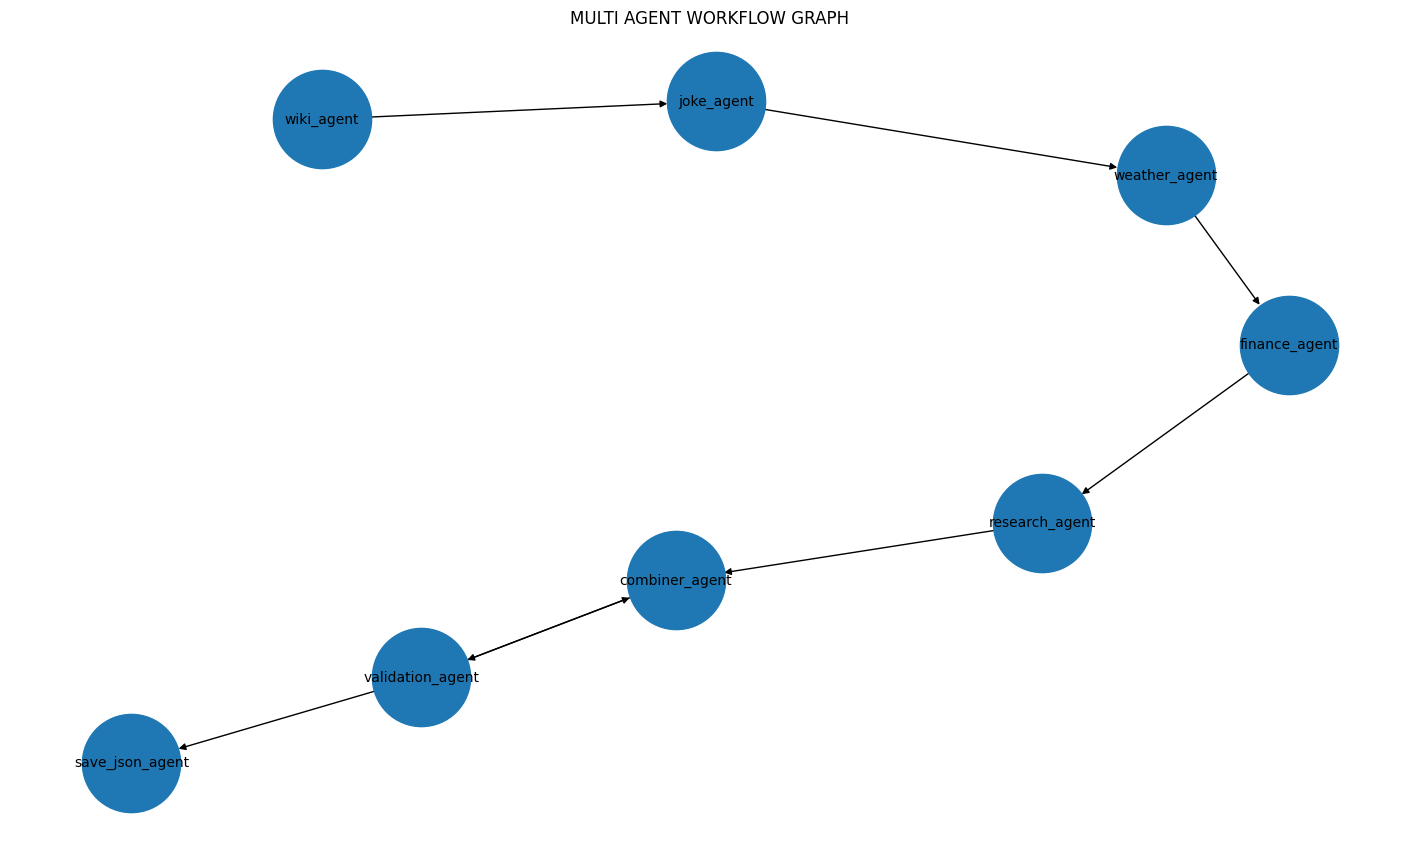


VALIDATION ATTEMPT: 1

JSON FILE SAVED SUCCESSFULLY

FINAL COMBINED OUTPUT
**Structured Response:**

**1. Definition of Artificial Intelligence:**
Artificial Intelligence (AI) is the simulation of human intelligence by machines.

**2. Humor:**
AI agents never sleep; they just keep prompting.

**3. Current Weather:**
The weather in Chennai is 34°C and sunny.

**4. Financial Update:**
Tesla stock has increased by 4.2% today.

**5. Research Insights:**
Recent research indicates that AI agents enhance automation and reasoning capabilities.

TOTAL RETRIES
1

JSON saved as: multi_agent_output.json


In [4]:
# ============================================================
# ADVANCED MULTI AGENT SYSTEM USING LANGGRAPH
# ============================================================
#
# FEATURES:
# 1. Multiple Specialized Agents
# 2. Multiple Dummy API Tools (No API Key Needed)
# 3. Retry Mechanism (10 retries)
# 4. Output Combiner Agent
# 5. Stores Outputs in JSON
# 6. Workflow Visualization
# 7. Latest LangChain + LangGraph Syntax
# 8. Google Colab Compatible
#
# ============================================================
# INSTALLATION
# ============================================================

# !pip install -qU langgraph langchain langchain-openai
!pip install langgraph grandalf networkx matplotlib

# ============================================================
# IMPORTS
# ============================================================

from google.colab import userdata

from typing import TypedDict, Annotated
import operator
import json
import random

from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI
from langchain.tools import tool
from langchain_core.messages import HumanMessage

import matplotlib.pyplot as plt
import networkx as nx

# ============================================================
# OPENAI API KEY FROM COLAB SECRETS
# ============================================================

OPENAI_API_KEY = userdata.get("OPENAI_API_KEY")

# ============================================================
# LLM
# ============================================================

llm = ChatOpenAI(
    model="gpt-4o-mini",
    api_key=OPENAI_API_KEY,
    temperature=0
)

# ============================================================
# DUMMY TOOLS (NO API KEY REQUIRED)
# ============================================================

@tool
def wikipedia_tool(topic: str) -> str:
    """Dummy Wikipedia Search Tool"""

    data = {
        "ai": "Artificial Intelligence is the simulation of human intelligence by machines.",
        "python": "Python is a high-level programming language.",
        "langgraph": "LangGraph helps build stateful multi-agent systems."
    }

    return data.get(topic.lower(), f"No Wikipedia data found for {topic}")


@tool
def joke_tool(query: str) -> str:
    """Dummy Joke Generator"""

    jokes = [
        "Why do programmers hate nature? Too many bugs.",
        "Why was Python angry? Because of indentation issues.",
        "AI agents never sleep. They just keep prompting."
    ]

    return random.choice(jokes)


@tool
def weather_tool(city: str) -> str:
    """Dummy Weather Tool"""

    return f"Weather in {city}: 34°C and Sunny."


@tool
def finance_tool(company: str) -> str:
    """Dummy Finance Tool"""

    return f"{company} stock increased by 4.2% today."


@tool
def research_tool(topic: str) -> str:
    """Dummy Research Tool"""

    return f"Research summary for {topic}: AI agents improve automation and reasoning."


tools = [
    wikipedia_tool,
    joke_tool,
    weather_tool,
    finance_tool,
    research_tool
]

# ============================================================
# STATE
# ============================================================

class AgentState(TypedDict):

    query: str

    wiki_output: str
    joke_output: str
    weather_output: str
    finance_output: str
    research_output: str

    combined_output: str

    retry_count: int
    validation_passed: bool

# ============================================================
# AGENTS
# ============================================================

def wiki_agent(state: AgentState):

    result = wikipedia_tool.invoke("AI")

    return {
        "wiki_output": result
    }


def joke_agent(state: AgentState):

    result = joke_tool.invoke("funny")

    return {
        "joke_output": result
    }


def weather_agent(state: AgentState):

    result = weather_tool.invoke("Chennai")

    return {
        "weather_output": result
    }


def finance_agent(state: AgentState):

    result = finance_tool.invoke("Tesla")

    return {
        "finance_output": result
    }


def research_agent(state: AgentState):

    result = research_tool.invoke("AI Agents")

    return {
        "research_output": result
    }

# ============================================================
# COMBINER AGENT
# ============================================================

def combiner_agent(state: AgentState):

    prompt = f"""
    Combine all these agent outputs into one structured response.

    Wikipedia:
    {state['wiki_output']}

    Joke:
    {state['joke_output']}

    Weather:
    {state['weather_output']}

    Finance:
    {state['finance_output']}

    Research:
    {state['research_output']}
    """

    response = llm.invoke([HumanMessage(content=prompt)])

    return {
        "combined_output": response.content
    }

# ============================================================
# VALIDATION + RETRY AGENT
# ============================================================

MAX_RETRIES = 10

def validation_agent(state: AgentState):

    retry = state["retry_count"] + 1

    print(f"\nVALIDATION ATTEMPT: {retry}")

    output = state["combined_output"]

    # Dummy Validation Logic
    validation_passed = len(output) > 100

    return {
        "retry_count": retry,
        "validation_passed": validation_passed
    }

# ============================================================
# CONDITIONAL ROUTING
# ============================================================

def retry_router(state: AgentState):

    if state["validation_passed"]:
        return "save"

    if state["retry_count"] >= MAX_RETRIES:
        return "save"

    return "retry"

# ============================================================
# SAVE JSON AGENT
# ============================================================

def save_json_agent(state: AgentState):

    final_data = {
        "query": state["query"],
        "wiki_output": state["wiki_output"],
        "joke_output": state["joke_output"],
        "weather_output": state["weather_output"],
        "finance_output": state["finance_output"],
        "research_output": state["research_output"],
        "combined_output": state["combined_output"],
        "retry_count": state["retry_count"]
    }

    with open("multi_agent_output.json", "w") as f:
        json.dump(final_data, f, indent=4)

    print("\nJSON FILE SAVED SUCCESSFULLY")

    return state

# ============================================================
# BUILD LANGGRAPH WORKFLOW
# ============================================================

builder = StateGraph(AgentState)

builder.add_node("wiki_agent", wiki_agent)
builder.add_node("joke_agent", joke_agent)
builder.add_node("weather_agent", weather_agent)
builder.add_node("finance_agent", finance_agent)
builder.add_node("research_agent", research_agent)

builder.add_node("combiner_agent", combiner_agent)

builder.add_node("validation_agent", validation_agent)

builder.add_node("save_json_agent", save_json_agent)

# ============================================================
# FLOW
# ============================================================

builder.set_entry_point("wiki_agent")

builder.add_edge("wiki_agent", "joke_agent")
builder.add_edge("joke_agent", "weather_agent")
builder.add_edge("weather_agent", "finance_agent")
builder.add_edge("finance_agent", "research_agent")

builder.add_edge("research_agent", "combiner_agent")

builder.add_edge("combiner_agent", "validation_agent")

builder.add_conditional_edges(
    "validation_agent",
    retry_router,
    {
        "retry": "combiner_agent",
        "save": "save_json_agent"
    }
)

builder.add_edge("save_json_agent", END)

graph = builder.compile()

# ============================================================
# VISUALIZE WORKFLOW
# ============================================================

workflow = nx.DiGraph()

workflow_edges = [
    ("wiki_agent", "joke_agent"),
    ("joke_agent", "weather_agent"),
    ("weather_agent", "finance_agent"),
    ("finance_agent", "research_agent"),
    ("research_agent", "combiner_agent"),
    ("combiner_agent", "validation_agent"),
    ("validation_agent", "combiner_agent"),
    ("validation_agent", "save_json_agent"),
]

workflow.add_edges_from(workflow_edges)

plt.figure(figsize=(14, 8))

pos = nx.spring_layout(workflow, seed=42)

nx.draw(
    workflow,
    pos,
    with_labels=True,
    node_size=5000,
    font_size=10,
    arrows=True
)

plt.title("MULTI AGENT WORKFLOW GRAPH")
plt.show()

# ============================================================
# RUN SYSTEM
# ============================================================

result = graph.invoke({

    "query": "Give me AI insights and some useful information",

    "wiki_output": "",
    "joke_output": "",
    "weather_output": "",
    "finance_output": "",
    "research_output": "",

    "combined_output": "",

    "retry_count": 0,
    "validation_passed": False
})

# ============================================================
# FINAL OUTPUT
# ============================================================

print("\n" + "="*60)
print("FINAL COMBINED OUTPUT")
print("="*60)

print(result["combined_output"])

print("\n" + "="*60)
print("TOTAL RETRIES")
print("="*60)

print(result["retry_count"])

print("\nJSON saved as: multi_agent_output.json")